In [8]:
import pandas as pd

In [9]:
from sklearn.datasets import make_regression

X, y = make_regression(
    n_samples=500,
    n_features=1,
    noise=30,
    random_state=42
)

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

LinearRegression()

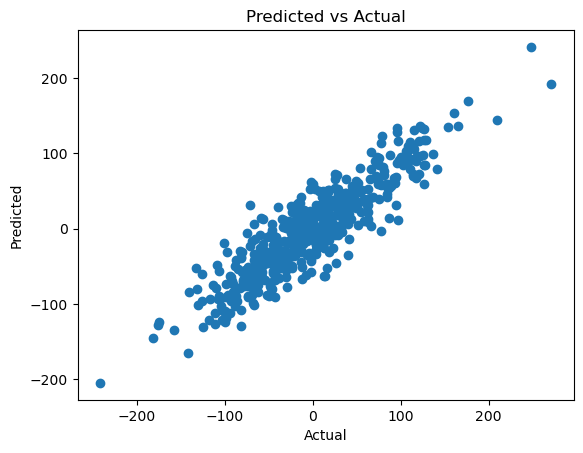

In [11]:
import matplotlib.pyplot as plt

predictions = model.predict(X)

plt.scatter(y, predictions)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.show()

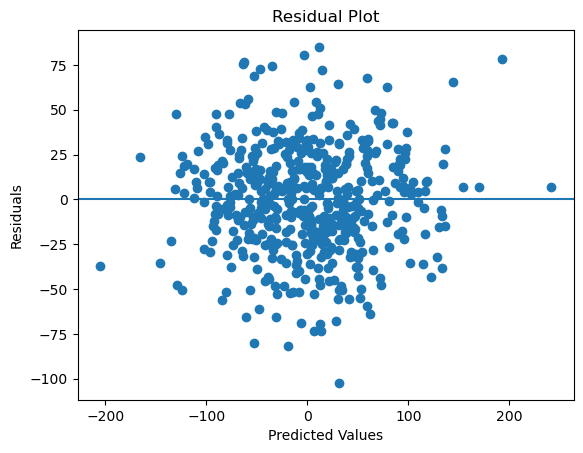

In [12]:
residuals = y - predictions

plt.scatter(predictions, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

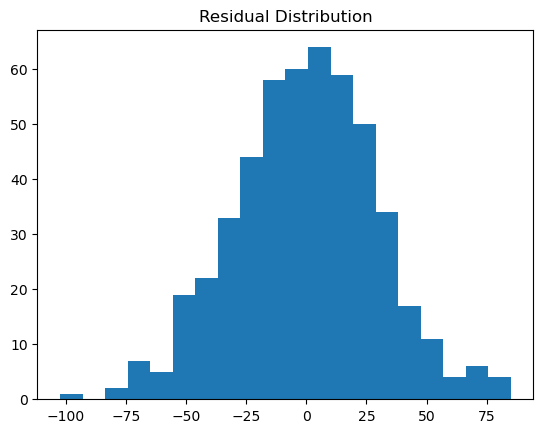

In [13]:
plt.hist(residuals, bins=20)
plt.title("Residual Distribution")
plt.show()

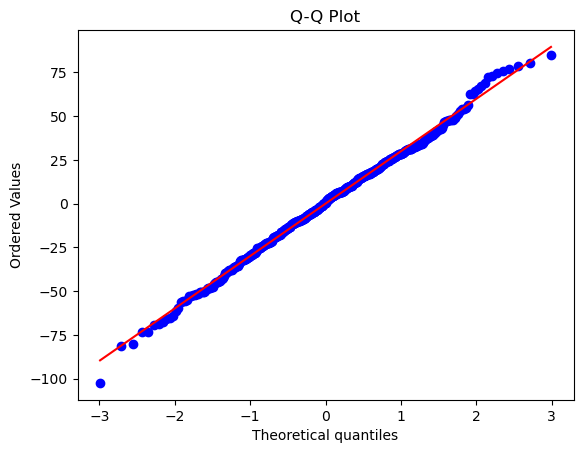

In [14]:
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

In [19]:
import pandas as pd
import numpy as np
np.random.seed(42)

n = 500

age = np.random.normal(45, 15, n)
bmi = np.random.normal(28, 5, n)
exercise_hours = np.random.normal(3, 2, n)

smoker = np.random.choice(
    [0,1],
    size=n,
    p=[0.8,0.2]
)

income = np.random.normal(
    55000,
    15000,
    n
)

healthcare_cost = (
    1000
    + age * 20
    + bmi * 40
    + smoker * 3000
    - exercise_hours * 100
    + np.random.normal(0,1000,n)
)

df = pd.DataFrame({
    'age': age,
    'bmi': bmi,
    'exercise_hours': exercise_hours,
    'smoker': smoker,
    'income': income,
    'healthcare_cost': healthcare_cost
})

In [20]:
df.loc[20:35,'income'] = np.nan
df.loc[50:60,'bmi'] = np.nan

In [21]:
df.loc[5,'income'] = 500000
df.loc[10,'healthcare_cost'] = 50000

In [22]:
df.isnull().sum()

age                 0
bmi                11
exercise_hours      0
smoker              0
income             16
healthcare_cost     0
dtype: int64

In [23]:
df.describe()

,age,bmi,exercise_hours,smoker,income,healthcare_cost
count,500.000000,489.000000,500.000000,500.000000,484.000000,500.000000
mean,45.102570,28.156351,3.216969,0.196000,55591.132871,3414.930791
std,14.718799,4.931527,2.020493,0.397366,24980.266811,2661.034592
min,-3.619010,14.515567,-2.792511,0.000000,9707.317663,-255.433697
25%,34.495389,24.936057,1.795141,0.000000,45177.191856,2244.812421
50%,45.191957,28.141592,3.239612,0.000000,54996.238528,3042.285282
75%,54.551749,31.292721,4.509477,0.000000,64777.191453,4095.476992
max,102.790972,41.161910,8.203366,1.000000,500000.000000,50000.000000


In [24]:
df.skew()

age                 0.180164
bmi                 0.052908
exercise_hours     -0.036397
smoker              1.536220
income             11.660725
healthcare_cost    10.944552
dtype: float64

In [25]:
df['income'] = df['income'].fillna(
    df['income'].median()
)

df['bmi'] = df['bmi'].fillna(
    df['bmi'].mean()
)

In [26]:
df.isnull().sum()

age                0
bmi                0
exercise_hours     0
smoker             0
income             0
healthcare_cost    0
dtype: int64

In [28]:
Q1 = df['income'].quantile(0.25)
Q3 = df['income'].quantile(0.75)

IQR = Q3 - Q1

In [29]:
upper = Q3 + 1.5*IQR

In [30]:
lower = Q1 - 1.5*IQR

In [31]:
outliers = df[
    (df['income'] > upper) |
    (df['income'] < lower)
]

print(len(outliers))

8


In [32]:
df['income'] = np.where(
    df['income'] > upper,
    upper,
    np.where(
        df['income'] < lower,
        lower,
        df['income']
    )
)

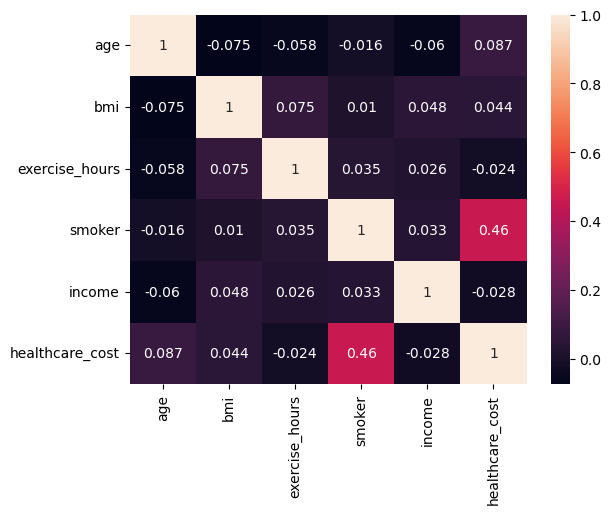

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.show()

In [34]:
from sklearn.linear_model import LinearRegression

X = df[
    ['age',
     'bmi',
     'smoker',
     'exercise_hours',
     'income']
]

y = df['healthcare_cost']

model = LinearRegression()

model.fit(X,y)

LinearRegression()

In [35]:
for name, coef in zip(
    X.columns,
    model.coef_
):
    print(name, coef)

age 16.929806849563533
bmi 27.98073246137429
smoker 3093.9804353852974
exercise_hours -50.07956152566827
income -0.007360062703878089


In [36]:
predictions = model.predict(X)

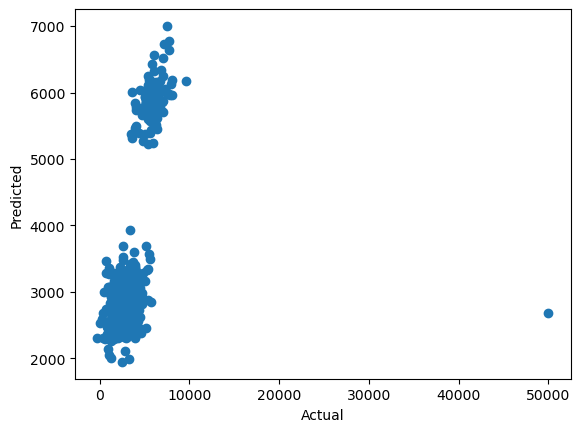

In [37]:
plt.scatter(
    y,
    predictions
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.show()

In [38]:
residuals = y - predictions

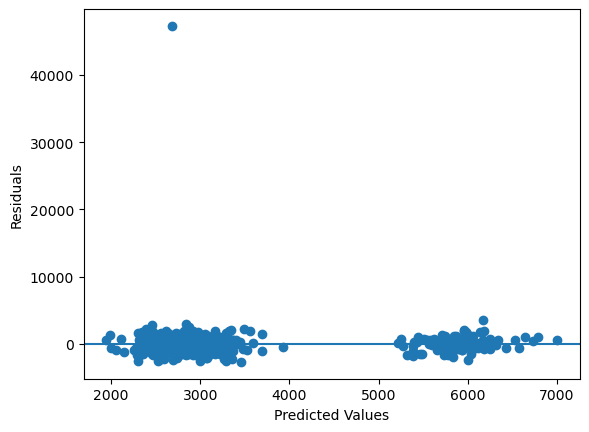

In [39]:
plt.scatter(
    predictions,
    residuals
)

plt.axhline(0)

plt.xlabel(
    "Predicted Values"
)

plt.ylabel(
    "Residuals"
)

plt.show()

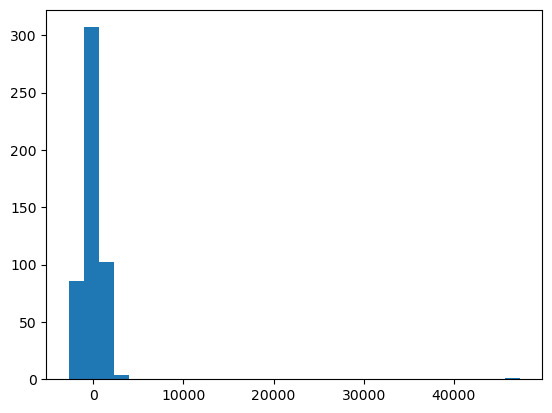

In [40]:
plt.hist(
    residuals,
    bins=30
)

plt.show()

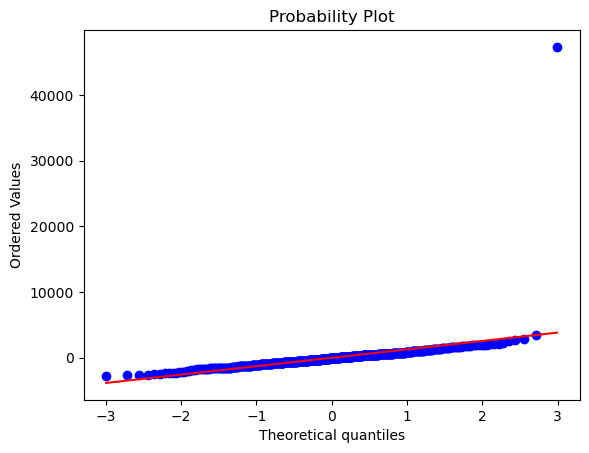

In [41]:
import scipy.stats as stats

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.show()